In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
data= r"C:\Users\Lenovo\OneDrive - Alexandria National University\Desktop\heart.csv"
df = pd.read_csv(data)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1024 non-null   float64
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1023 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1024.000000,1025.000000,1025.000000,1023.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529297,149.114146,0.336585,1.072043,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527931,23.005724,0.472772,1.176008,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(720)

In [6]:
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,44,0,2,108,141,0,1.0,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1.0,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0.0,125,0,0.0,2,0,2,0
873,57,1,0,140,192,0,1.0,148,0,0.4,1,0,1,1


In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df["restecg"]=df["restecg"].fillna(df["restecg"].median())
df["oldpeak"]=df["oldpeak"].fillna(df["oldpeak"].median())

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

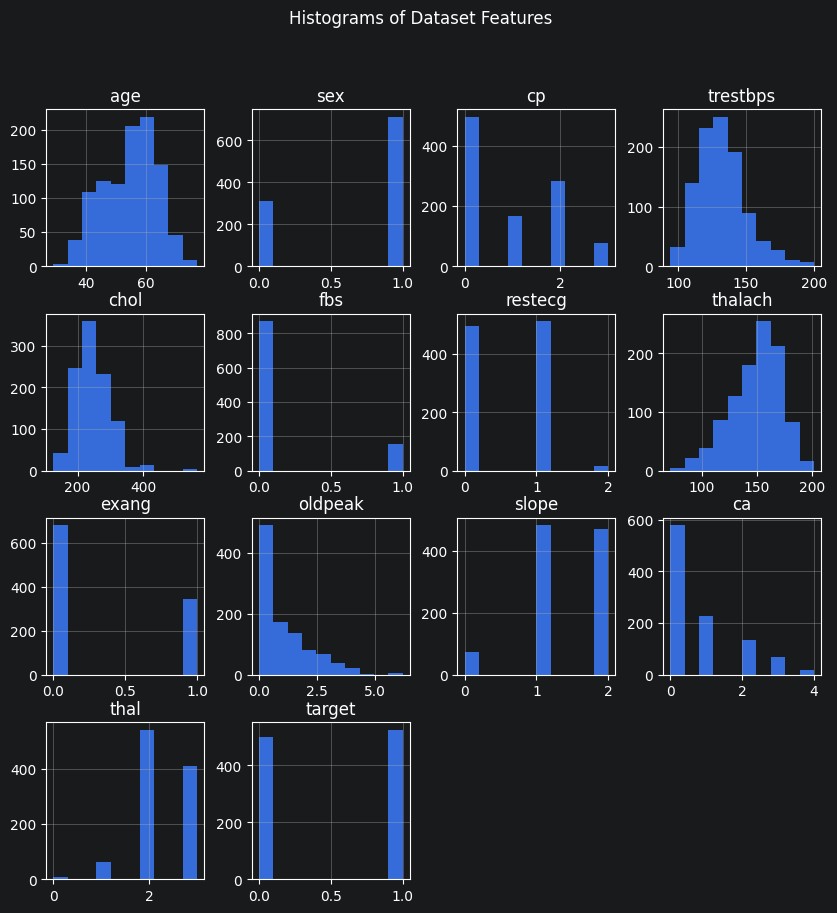

In [10]:
df.hist(figsize=(10,10))
plt.suptitle("Histograms of Dataset Features")
plt.show()

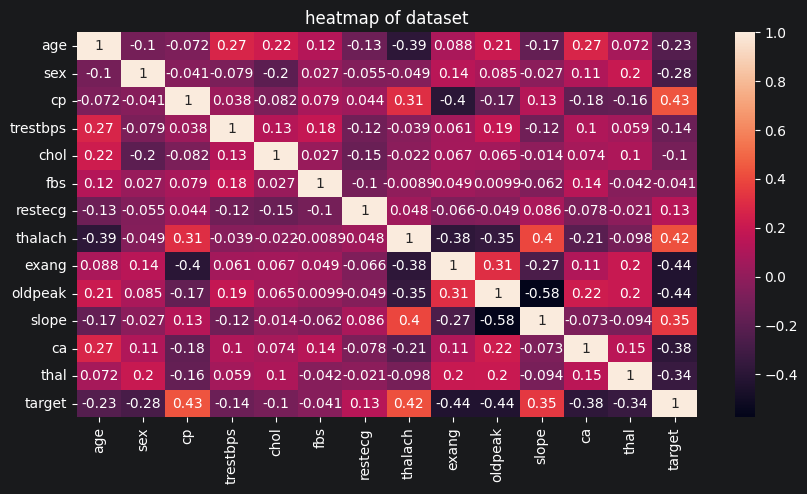

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True)
plt.title("heatmap of dataset")
plt.show()

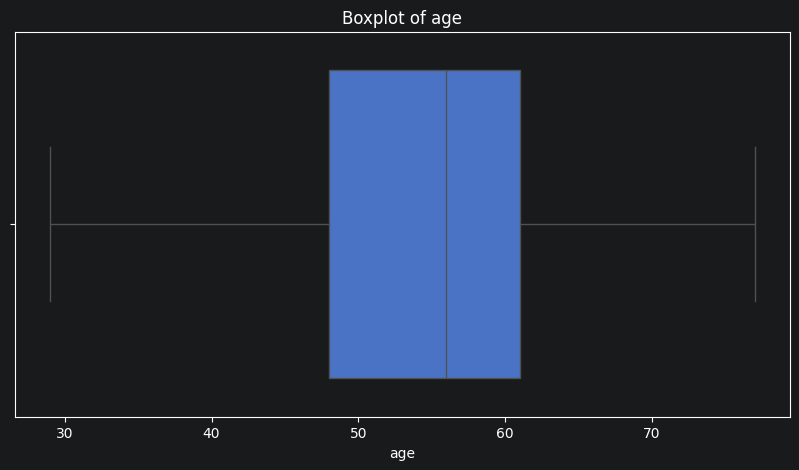

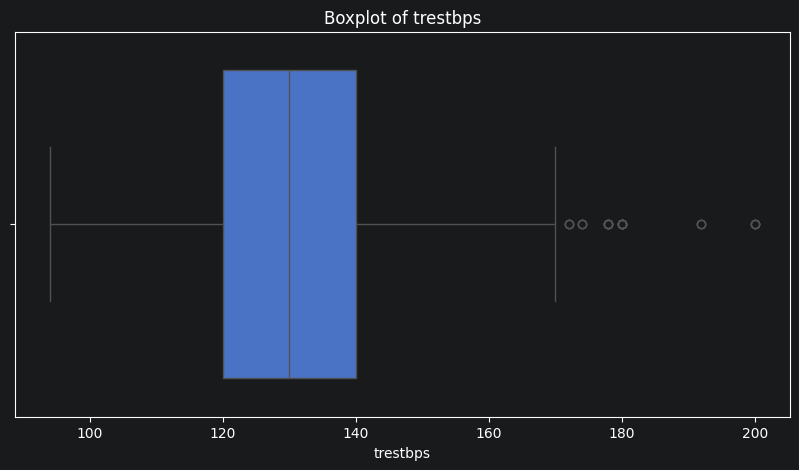

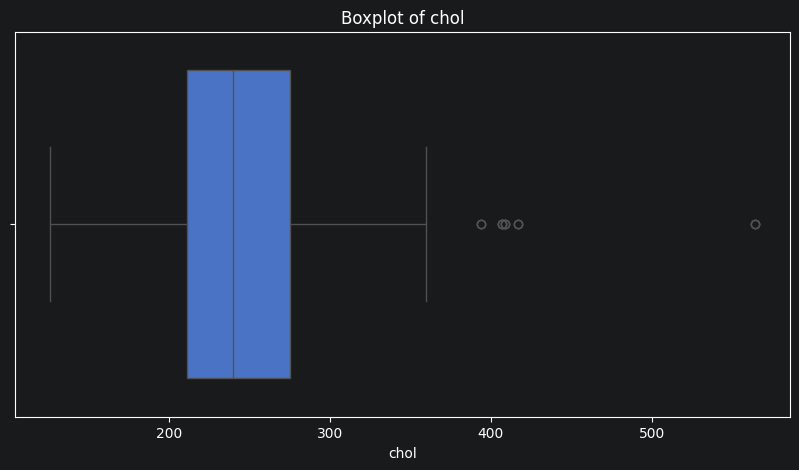

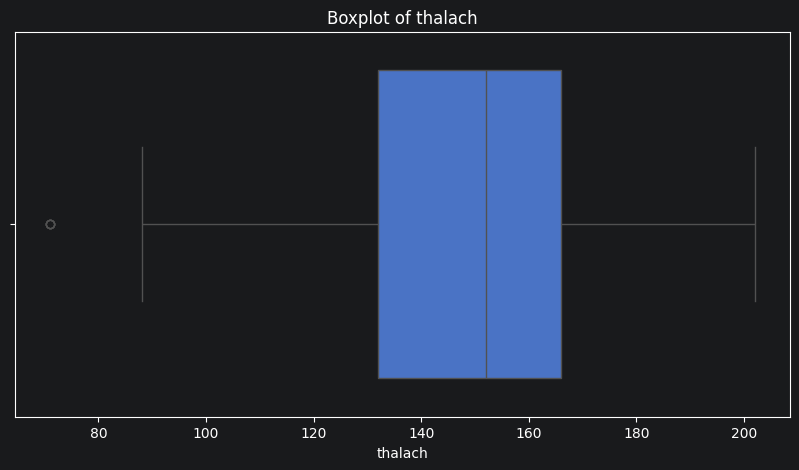

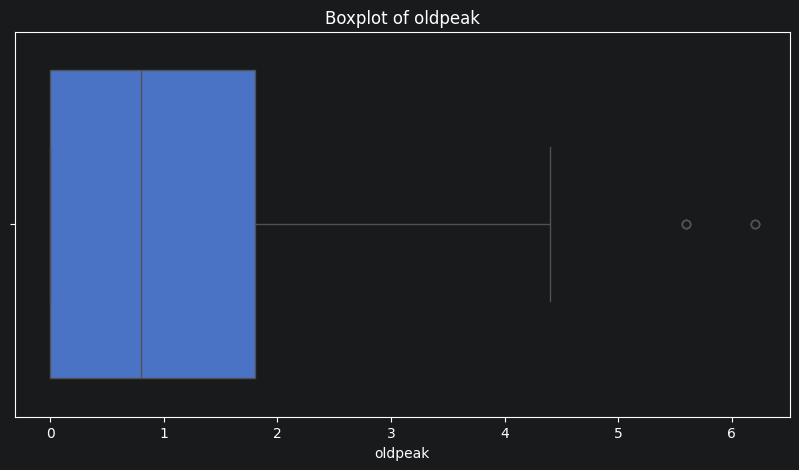

In [12]:

feature = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in feature:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [13]:
x =df.drop("target",axis=1)
y=df["target"]

In [14]:
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

In [15]:
joblib.dump(scaler,"scaler of dataset")

['scaler of dataset']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [17]:
def expert_system(patient):
    score = 0
    if patient.get("age", 0) > 55:
        score += 1
    if patient.get("chol", 0) > 240:
        score += 1
    if patient.get("Exercise",0) == 'Regular' and patient.get('BMI') < 25:
         score -= 1
    if patient.get("trestbps", 0) > 140:
        score += 1
    if patient.get("exang", 0) == 1:
        score += 1
    if patient.get("oldpeak", 0) > 2:
        score += 1
    if patient.get("ca", 0) >= 2:
        score += 1
    if patient.get("thal", 0) == 3:
        score += 1
    if patient.get("cp", 0) == 0:
        score += 1
    if patient.get("thalach", 0) < 120:
        score += 1
    if patient.get("fbs", 0) == 1:
        score += 1
    return 1 if score >= 5 else 0

In [18]:
p={
    "max_depth":[3,6,8,10],
    "min_samples_split":[2,6,10]
}

In [19]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=p,
    cv=5,
    scoring='accuracy')

In [20]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 6, ...], 'min_samples_split': [2, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [21]:
model=grid.best_estimator_
y_pred =model.predict(x_test)

In [22]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 2}


In [23]:
ml_accuracy = accuracy_score(y_test, y_pred)
ml_precision = precision_score(y_test, y_pred)
ml_recall = recall_score(y_test, y_pred)
ml_f1 = f1_score(y_test, y_pred)

In [24]:
print("Accuracy :",ml_accuracy)
print("precision :",ml_precision)
print("recall :",ml_recall)
print("f1 :",ml_f1)

Accuracy : 0.9707792207792207
precision : 1.0
recall : 0.9395973154362416
f1 : 0.9688581314878892


In [25]:
joblib.dump(model,"heart_disease")

['heart_disease']

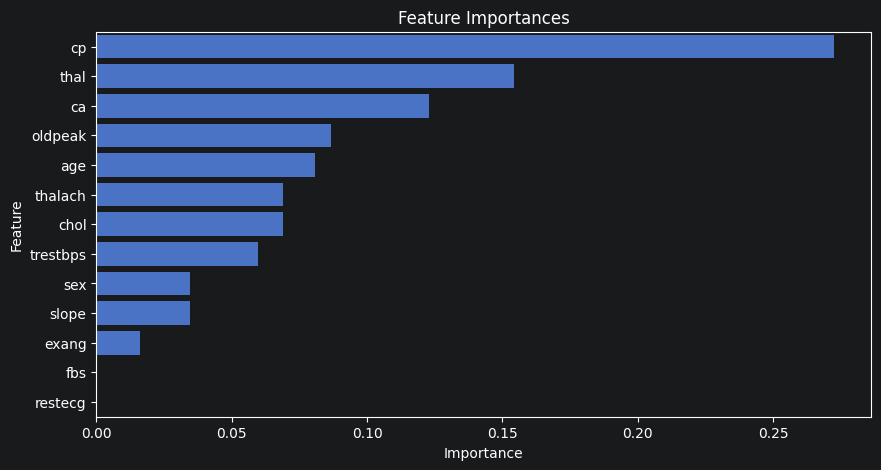

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

f = pd.Series(model.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=f.values, y=f.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [27]:
test_row=df.loc[x_test.index, x.columns]
expert_predictions = []

In [28]:
for _, row in test_row.iterrows():
    patient = row.to_dict()
    prediction = expert_system(patient)
    expert_predictions.append(prediction)

expert_accuracy = accuracy_score(y_test, expert_predictions)

In [29]:
print("Expert System Accuracy :",expert_accuracy)
print("Decision Tree Accuracy :",ml_accuracy)

Expert System Accuracy : 0.29545454545454547
Decision Tree Accuracy : 0.9707792207792207


In [30]:
if ml_accuracy > expert_accuracy:
    print("Decision Tree better than the Expert System.")
elif expert_accuracy > ml_accuracy:
    print("Expert System better than the Decision Tree.")
else:
    print("Both systems achieved the same accuracy.")


Decision Tree better than the Expert System.


In [31]:
with open("accuracy_comparison.txt", "w", encoding="utf-8") as file:
    file.write("Heart Disease Detection Project\n")
    file.write("Decision Tree Results:\n")
    file.write(f"Best Parameters: {grid.best_params_}\n")
    file.write(f"Accuracy : {ml_accuracy}\n")
    file.write(f"Precision: {ml_precision}\n")
    file.write(f"Recall   : {ml_recall}\n")
    file.write(f"F1-Score : {ml_f1}\n\n")

    file.write("Expert System Results:\n")
    file.write(f"Accuracy : {expert_accuracy}\n\n")

    file.write("Conclusion:\n")
    if ml_accuracy > expert_accuracy:
        file.write("Decision Tree better than the Expert System.\n")
    elif expert_accuracy > ml_accuracy:
        file.write("The rule-based expert system better than the Decision Tree model.\n")
    else:
        file.write("Both systems achieved the same performance.\n")




In [32]:
sample_patient = {
    "age": 60,
    "sex": 1,
    "cp": 0,
    "trestbps": 145,
    "chol": 250,
    "fbs": 1,
    "restecg": 1,
    "thalach": 110,
    "exang": 1,
    "oldpeak": 2.5,
    "slope": 0,
    "ca": 2,
    "thal": 3
}

sample_result = expert_system(sample_patient)

print("Sample Patient Test Using Expert System:")
if sample_result == 1:
    print("Heart Disease")
else:
    print("No Heart Disease")

Sample Patient Test Using Expert System:
Heart Disease
